![jupyter](img/logoItq.png)

**Nombre:** *Adrián Falcones*

# **Examen Practico - Segundo Parcial**

![jupyter](img/logoPy.png)

## Cargar una de las imágenes histológicas

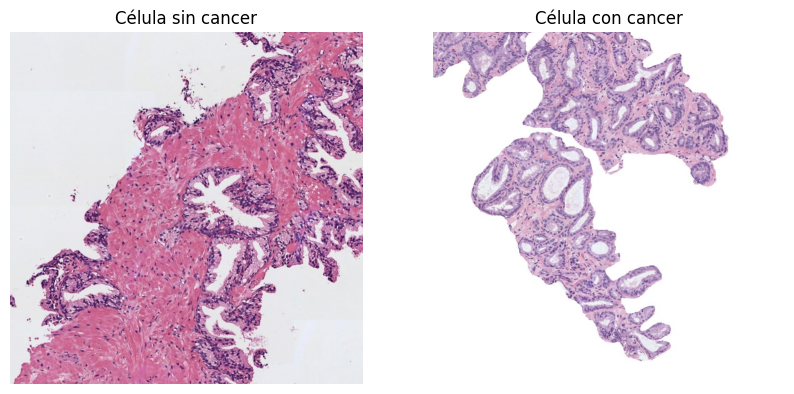

In [1]:
# 1) Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
from skimage.filters import gaussian, threshold_otsu #Filtro gausiano y el método otsu (umbral calculado automáticamente)
from skimage.morphology import remove_small_objects #con esta librería podremos quitar los pequeños puntos blancos
from skimage.segmentation import flood #usaremos esto para hacer region growing desde cada semilla
from scipy.ndimage import binary_fill_holes  # Para rellenar los agujeros
from skimage.measure import find_contours #Para poder realizar los contornos
from skimage.measure import label, regionprops #etiquetamos los lúmenes con label y calculamos las propiedades con regionprops

img1 = io.imread('histo_1.jpg') #Esta no tiene cancer
img2 = io.imread('histo_2.jpg') #Esta si tiene cancer

# 2) Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
img1_norm = img1 / 255.0
img2_norm = img2 / 255.0

# 3) Visualizar la imagen
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1_norm)
plt.title("Célula sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_norm)
plt.title("Célula con cancer")
plt.axis('off')

plt.show()

## Realizar una transformación de color para convertir la imagen al espacio de color CMYK

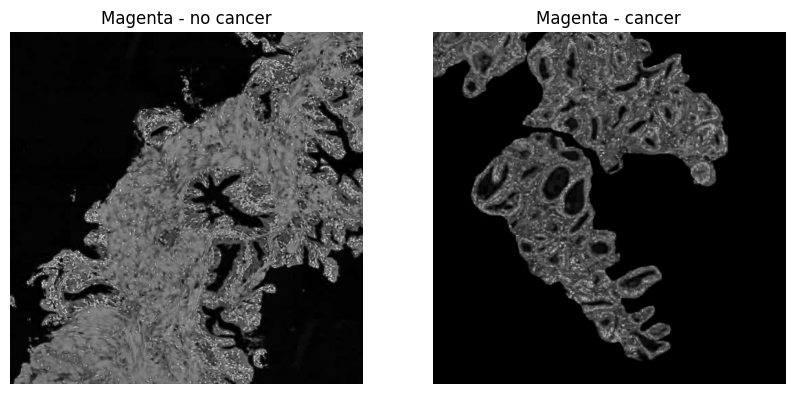

In [2]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)

#1) Vamos a cambiar de RGB a CMYK

#1.1) Célula sin cancer

R1 = img1_norm[:,:,0]
G1 = img1_norm[:,:,1]
B1 = img1_norm[:,:,2]

K1 = 1 - np.max(img1_norm, axis=2)
epsilon = 1e-8

M1 = (1 - G1 - K1) / (1 - K1 + epsilon)
M1 = np.clip(M1, 0, 1)

#1.2) Célula con cancer
R2 = img2_norm[:,:,0]
G2 = img2_norm[:,:,1]
B2 = img2_norm[:,:,2]

K2 = 1 - np.max(img2_norm, axis=2)

M2 = (1 - G2 - K2) / (1 - K2 + epsilon)
M2 = np.clip(M2, 0, 1)

# Visualizar la imagen del canal magenta
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(M1, cmap='gray')
plt.title("Magenta - no cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(M2, cmap='gray')
plt.title("Magenta - cancer")
plt.axis('off')

plt.show()

## Umbralizar la imagen para separar los píxeles del fondo de la región tisular

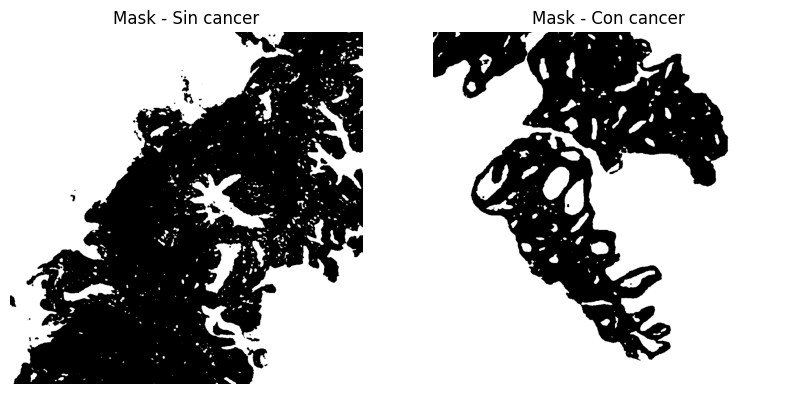

In [3]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".

#2.1) Imagen sin cancer

# Filtro gaussiano
M1_smooth = gaussian(M1, sigma=1)  # aprox 5x5

# Convertir a uint8 [0-255]
M1_uint8 = (M1_smooth * 255).astype(np.uint8)

# Método Otsu
th1 = threshold_otsu(M1_uint8)

# Crear máscara (lumen + fondo = 1)
mask1 = M1_uint8 < th1


#2.2) Imagen con cancer
M2_smooth = gaussian(M2, sigma=1)
M2_uint8 = (M2_smooth * 255).astype(np.uint8)

th2 = threshold_otsu(M2_uint8)

mask2 = M2_uint8 < th2


#2.3) Visualizar la máscara resultante
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask1, cmap='gray')
plt.title("Mask - Sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask2, cmap='gray')
plt.title("Mask - Con cancer")
plt.axis('off')

plt.show()

## Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

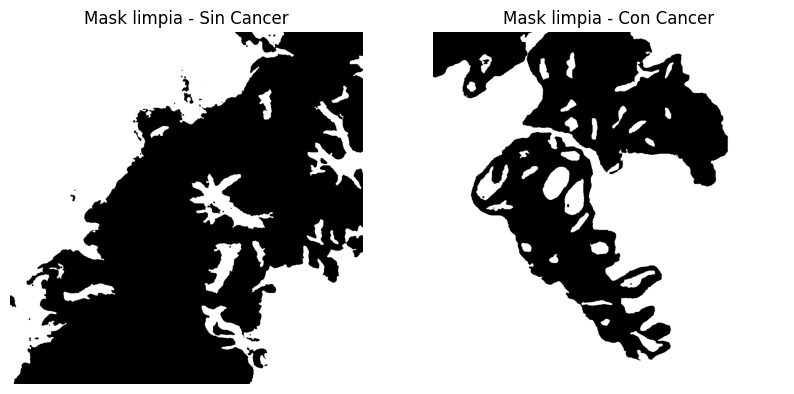

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects

# Imagen sin cancer
mask1_clean = remove_small_objects(mask1.astype(bool), max_size=300)

# Imagen con cancer
mask2_clean = remove_small_objects(mask2.astype(bool), max_size=300)

# Visualizaer la máscara resultante
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask1_clean, cmap='gray')
plt.title("Mask limpia - Sin Cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask2_clean, cmap='gray')
plt.title("Mask limpia - Con Cancer")
plt.axis('off')

plt.show()

## Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

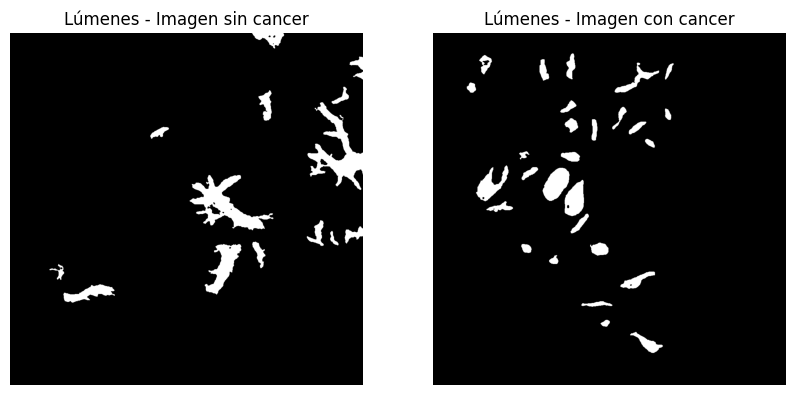

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
def obtener_lumen(mask):
    mask = mask.astype(bool)
    
    # Crear máscara de fondo que inicialmente será vacía
    fondo = np.zeros_like(mask, dtype=bool)
    
    # Semillas automáticas en esquinas, con esto aseguramos el fondo
    seeds = [(0,0), (0,-1), (-1,0), (-1,-1)]
    
    for seed in seeds:
        fondo = fondo | flood(mask, seed_point=seed, connectivity=1)
    
    # Con esto eliminamos el fondo y nos quedamos únicamente con los lúmenes 
    lumen = mask & (~fondo)
    
    return lumen

lumen1 = obtener_lumen(mask1_clean)
lumen2 = obtener_lumen(mask2_clean)
    
# Visualizar la máscara resultante. 
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(lumen1, cmap='gray')
plt.title("Lúmenes - Imagen sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lumen2, cmap='gray')
plt.title("Lúmenes - Imagen con cancer")
plt.axis('off')

plt.show()

## Rellenar los objetos de los lúmenes

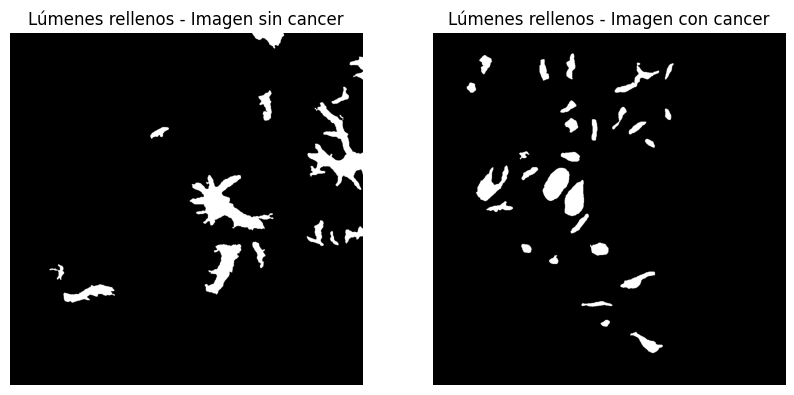

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
lumen1_filled = binary_fill_holes(lumen1)
lumen2_filled = binary_fill_holes(lumen2)

# Visualizar la máscara resultante
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(lumen1_filled, cmap='gray')
plt.title("Lúmenes rellenos - Imagen sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lumen2_filled, cmap='gray')
plt.title("Lúmenes rellenos - Imagen con cancer")
plt.axis('off')

plt.show()

## Detectar y dibujar los contornos de los lúmenes sobre la imagen original

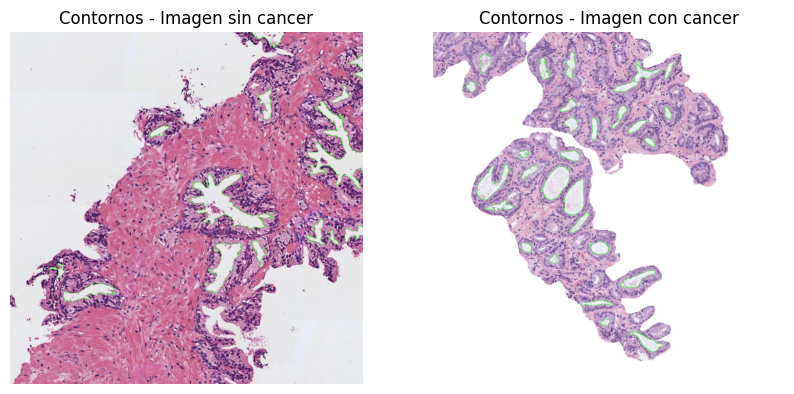

In [7]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 

#1) Creamos una función para los contornos de la img

def dibujar_los_contornos(image, mask):
    img_out = image.copy()

    # Encontrar contornos
    contours = find_contours(mask, level=0.5)

    for contour in contours:
        contour = contour.astype(int)
        
        # Dibujar en verde (R=0, G=1, B=0)
        img_out[contour[:,0], contour[:,1]] = [0, 1, 0]

    return img_out

#2) Aplicamos la función para ambas imágenes
img1_contours = dibujar_los_contornos(img1_norm, lumen1_filled)
img2_contours = dibujar_los_contornos(img2_norm, lumen2_filled)

# Visualizar la imagen superpuesta

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1_contours)
plt.title("Contornos - Imagen sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_contours)
plt.title("Contornos - Imagen con cancer")
plt.axis('off')

plt.show()

## Identificar y cropear el lumen más grande

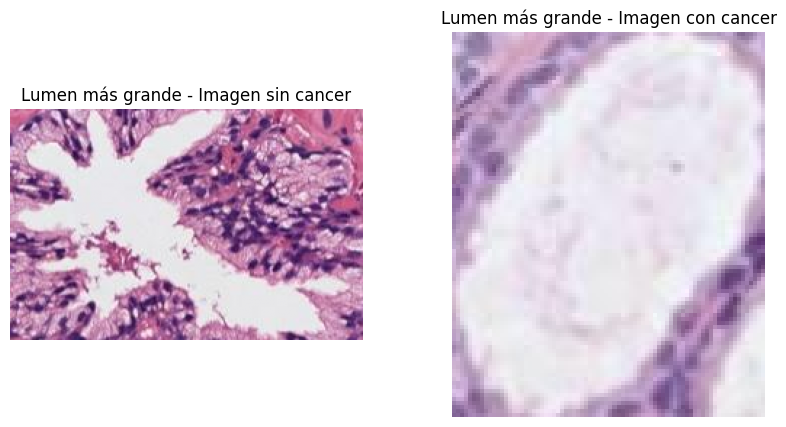

In [8]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
#1) Función para ver el Lumen más potente
def obtener_recorte_lumen_alto(image, mask):
    
    # 1.1) Etiquetar componentes
    labeled = label(mask)
    
    # 1.2) Obtener propiedades
    regions = regionprops(labeled)
    
    # 1.3) Encontrar el de mayor área
    largest_region = max(regions, key=lambda r: r.area)
    
    # 1.4) Bounding box
    minr, minc, maxr, maxc = largest_region.bbox
    
    # 1.5) Crop sobre imagen original
    crop = image[minr:maxr, minc:maxc]
    
    return crop

#2) Aplicamos a las imágenes
crop1 = obtener_recorte_lumen_alto(img1_norm, lumen1_filled)
crop2 = obtener_recorte_lumen_alto(img2_norm, lumen2_filled)


# Visualizar el lumen cropeado.
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(crop1)
plt.title("Lumen más grande - Imagen sin cancer")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(crop2)
plt.title("Lumen más grande - Imagen con cancer")
plt.axis('off')

plt.show()

## Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [11]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.

#1) Creamos una función para ver las características del lumen

def extract_features(mask):
    
    labeled = label(mask)
    regions = regionprops(labeled)
    
    # Vemos el lumen más grande
    region = max(regions, key=lambda r: r.area)
    
    #Características
    
    # 1.1) Área
    area = region.area
    # 1.2) Área de la bounding box 
    bbox_area = region.area_bbox
    # 1.3) Área convexa
    convex_area = region.area_convex
    # 1.4) Exentricidad
    eccentricity = region.eccentricity
    # 1.5) Diámetro que será equivalente
    equiv_diameter = region.equivalent_diameter_area
    # 1.6) Extensión
    extent = region.extent
    # 1.7) Longitud del eje mayor
    major_axis = region.axis_major_length
    # 1.8) Longitud del eje menor
    minor_axis = region.axis_minor_length
    # 1.9) Orientación
    orientation = region.orientation
    # 1.10) Perímetro
    perimeter = region.perimeter
    # 1.11) Solidez
    solidity = region.solidity
    
  # 1.7) Diámetro Feret
    feret_diameter = major_axis #una aprox
    
    
    #Compacidad
    compactness = (perimeter**2) / (4 * np.pi * area)
    
   
    # Redondeo a 4 decimales (para que no salga mucho xd)
    features = {
        "Área": round(area, 4),
        "Área del BBox": round(bbox_area, 4),
        "Área Convexa": round(convex_area, 4),
        "Excentricidad": round(eccentricity, 4),
        "Diametro Equivalente": round(equiv_diameter, 4),
        "Extensión": round(extent, 4),
        "Diámetro Equivalente": round(feret_diameter, 4),
        "Eje Mayor": round(major_axis, 4),
        "Eje Menor": round(minor_axis, 4),
        "Orientación": round(orientation, 4),
        "Perímetro": round(perimeter, 4),
        "Solidez": round(solidity, 4),
        "Compacidad": round(compactness, 4)
    }
    
    return features

In [12]:
#2) Le aplicamos a ambas imágenes
features1 = extract_features(lumen1_filled)
features2 = extract_features(lumen2_filled)

#3) Mostramos el resultado
print("Features Sin Cancer:\n", features1)
print("\nFeatures Con Cancer:\n", features2)

Features Sin Cancer:
 {'Área': np.float64(13925.0), 'Área del BBox': np.float64(38880.0), 'Área Convexa': np.float64(28787.0), 'Excentricidad': 0.8458, 'Diametro Equivalente': np.float64(133.1535), 'Extensión': np.float64(0.3582), 'Diámetro Equivalente': 236.5355, 'Eje Mayor': 236.5355, 'Eje Menor': 126.2076, 'Orientación': 1.0125, 'Perímetro': np.float64(1198.0052), 'Solidez': np.float64(0.4837), 'Compacidad': np.float64(8.2019)}

Features Con Cancer:
 {'Área': np.float64(4855.0), 'Área del BBox': np.float64(7488.0), 'Área Convexa': np.float64(4988.0), 'Excentricidad': 0.8349, 'Diametro Equivalente': np.float64(78.623), 'Extensión': np.float64(0.6484), 'Diámetro Equivalente': 106.201, 'Eje Mayor': 106.201, 'Eje Menor': 58.453, 'Orientación': -0.5605, 'Perímetro': np.float64(279.8061), 'Solidez': np.float64(0.9733), 'Compacidad': np.float64(1.2833)}


# GitHub 

- [https://github.com/ndadri/Cuaderno_python2](https://github.com/ndadri/Cuaderno_python2) 